2025-04-30 12:19:12,129 - STPSimulator - INFO - [12:19:12] Switch 1: Connected port 1 to Switch 2's port 1
2025-04-30 12:19:26,102 - STPSimulator - INFO - [12:19:26] Switch 1: Starting STP
2025-04-30 12:19:26,102 - STPSimulator - INFO - Switch 1 listening on 127.0.0.1:40942
2025-04-30 12:19:26,102 - STPSimulator - INFO - [12:19:26] Switch 2: Starting STP
2025-04-30 12:19:26,113 - STPSimulator - INFO - Switch 2 listening on 127.0.0.2:11751
2025-04-30 12:19:27,111 - STPSimulator - INFO - [12:19:27] Switch 2: New root bridge: 1 (was 2), new root port: 1, cost: 19
2025-04-30 12:19:27,116 - STPSimulator - INFO - [12:19:27] Switch 1: Sent BPDU [Root: 1, Cost: 0, Sender: 1, Port: 1] on port 1
2025-04-30 12:19:27,117 - STPSimulator - INFO - [12:19:27] Switch 1: Port 1 is now a designated port
2025-04-30 12:19:27,120 - STPSimulator - INFO - [12:19:27] Switch 2: Sent BPDU [Root: 1, Cost: 19, Sender: 2, Port: 1] on port 1
2025-04-30 12:19:29,118 - STPSimulator - INFO - [12:19:29] Switch 1: Sent B

KeyboardInterrupt: 

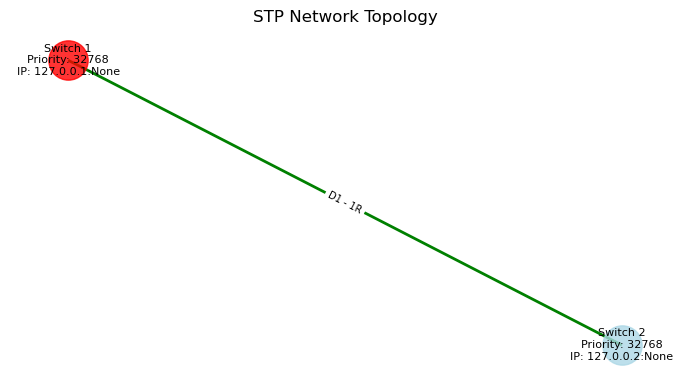

2025-04-30 12:21:49,411 - STPSimulator - INFO - [12:21:49] Switch 1: Sent BPDU [Root: 1, Cost: 0, Sender: 1, Port: 1] on port 1
2025-04-30 12:21:49,456 - STPSimulator - INFO - [12:21:49] Switch 2: Sent BPDU [Root: 1, Cost: 19, Sender: 2, Port: 1] on port 1
2025-04-30 12:21:51,414 - STPSimulator - INFO - [12:21:51] Switch 1: Sent BPDU [Root: 1, Cost: 0, Sender: 1, Port: 1] on port 1
2025-04-30 12:21:51,458 - STPSimulator - INFO - [12:21:51] Switch 2: Sent BPDU [Root: 1, Cost: 19, Sender: 2, Port: 1] on port 1
2025-04-30 12:21:53,416 - STPSimulator - INFO - [12:21:53] Switch 1: Sent BPDU [Root: 1, Cost: 0, Sender: 1, Port: 1] on port 1
2025-04-30 12:21:53,460 - STPSimulator - INFO - [12:21:53] Switch 2: Sent BPDU [Root: 1, Cost: 19, Sender: 2, Port: 1] on port 1
2025-04-30 12:21:55,418 - STPSimulator - INFO - [12:21:55] Switch 1: Sent BPDU [Root: 1, Cost: 0, Sender: 1, Port: 1] on port 1
2025-04-30 12:21:55,462 - STPSimulator - INFO - [12:21:55] Switch 2: Sent BPDU [Root: 1, Cost: 19, Se

In [1]:
#!/usr/bin/env python3

"""
STP Simulation - Spanning Tree Protocol Simulator with Network Support

This application simulates the operation of the Spanning Tree Protocol (STP)
on network switches, focusing on how switches elect a root bridge and
build a loop-free topology. Enhanced with socket programming to support
distributed operation across multiple hosts.
"""

import random
import time
import threading
import copy
import tkinter as tk
from tkinter import ttk, simpledialog, messagebox
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import socket
import json
import pickle
import struct
import uuid
import ipaddress
import logging
import queue

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger('STPSimulator')

class BPDUMessage:
    """Bridge Protocol Data Unit (BPDU) message for STP"""
    
    def __init__(self, root_bridge_id, root_path_cost, sender_bridge_id, sender_port_id, 
                 sender_address=None, sender_port=None):
        self.root_bridge_id = root_bridge_id
        self.root_path_cost = root_path_cost
        self.sender_bridge_id = sender_bridge_id
        self.sender_port_id = sender_port_id
        # Network information for socket communication
        self.sender_address = sender_address  # IP address of sender
        self.sender_port = sender_port  # TCP port of sender
        self.message_id = str(uuid.uuid4())  # Unique ID to avoid duplicate processing
        
    def __str__(self):
        return (f"BPDU [Root: {self.root_bridge_id}, Cost: {self.root_path_cost}, "
                f"Sender: {self.sender_bridge_id}, Port: {self.sender_port_id}]")
    
    def to_dict(self):
        """Convert BPDU to dictionary for network transmission"""
        return {
            'root_bridge_id': self.root_bridge_id,
            'root_path_cost': self.root_path_cost,
            'sender_bridge_id': self.sender_bridge_id,
            'sender_port_id': self.sender_port_id,
            'sender_address': self.sender_address,
            'sender_port': self.sender_port,
            'message_id': self.message_id
        }
    
    @classmethod
    def from_dict(cls, data):
        """Create BPDU from dictionary (received from network)"""
        bpdu = cls(
            data['root_bridge_id'],
            data['root_path_cost'],
            data['sender_bridge_id'],
            data['sender_port_id'],
            data['sender_address'],
            data['sender_port']
        )
        bpdu.message_id = data['message_id']
        return bpdu

class Port:
    """Switch port that connects to other switches or hosts"""
    
    # Port Role States
    ROOT_PORT = "Root Port"
    DESIGNATED_PORT = "Designated Port"
    BLOCKED_PORT = "Blocked Port"
    ALTERNATE_PORT = "Alternate Port"
    
    # Port States
    LISTENING = "Listening"
    LEARNING = "Learning"
    FORWARDING = "Forwarding"
    BLOCKING = "Blocking"
    
    def __init__(self, port_id, switch):
        self.port_id = port_id
        self.switch = switch
        self.connected_to = None  # Can be a Port object (local) or NetworkPort object (remote)
        self.role = None
        self.state = self.LISTENING
        self.path_cost = 19  # Default cost for 100 Mbps link according to IEEE 802.1D
        
        # STP parameters
        self.designated_root = None
        self.root_path_cost = float('inf')
        self.designated_bridge = None
        self.designated_port = None
        
        # For network operation
        self.is_networked = False
        self.remote_switch_id = None
        self.remote_ip = None
        self.remote_port = None
        
    def __str__(self):
        if self.is_networked and self.remote_ip:
            connected_to_str = f"Switch {self.remote_switch_id} at {self.remote_ip}:{self.remote_port}"
        elif self.connected_to:
            connected_to_str = f"{self.connected_to.switch.bridge_id}:{self.connected_to.port_id}"
        else:
            connected_to_str = "None"
            
        return (f"Port {self.port_id} - State: {self.state}, Role: {self.role}, "
                f"Connected to: {connected_to_str}")
    
    def receive_bpdu(self, bpdu):
        """Process received BPDU message"""
        self.switch.process_bpdu(bpdu, self.port_id)
    
    def send_bpdu(self):
        """Send BPDU through this port"""
        if self.state == self.BLOCKING:
            return None
            
        bpdu = BPDUMessage(
            self.switch.root_bridge_id,
            self.switch.root_path_cost,
            self.switch.bridge_id,
            self.port_id,
            self.switch.ip_address,
            self.switch.tcp_port
        )
        
        if self.is_networked and self.remote_ip:
            # Send BPDU over network to remote switch
            self.switch.send_network_bpdu(bpdu, self.remote_ip, self.remote_port)
            return bpdu
        elif self.connected_to:
            # Direct in-memory delivery for local simulation
            self.connected_to.receive_bpdu(bpdu)
            return bpdu
            
        return None
    
    def update_state(self):
        """Update port state based on its role"""
        if self.role == self.ROOT_PORT or self.role == self.DESIGNATED_PORT:
            # Transition from LISTENING to LEARNING to FORWARDING
            if self.state == self.LISTENING:
                self.state = self.LEARNING
            elif self.state == self.LEARNING:
                self.state = self.FORWARDING
        elif self.role == self.BLOCKED_PORT or self.role == self.ALTERNATE_PORT:
            self.state = self.BLOCKING
    
    def set_remote_connection(self, remote_switch_id, remote_ip, remote_port, remote_port_id):
        """Configure this port for a network connection"""
        self.is_networked = True
        self.remote_switch_id = remote_switch_id
        self.remote_ip = remote_ip
        self.remote_port = remote_port
        self.remote_port_id = remote_port_id
        
        # Create a virtual port to track the remote state
        class NetworkPort:
            def __init__(self, switch_id, port_id):
                self.switch = type('', (), {})()  # Empty object
                self.switch.bridge_id = switch_id
                self.port_id = port_id
                self.state = Port.LISTENING
                self.role = None
                
        self.connected_to = NetworkPort(remote_switch_id, remote_port_id)
        
class NetworkManager:
    """Manages network communications for a switch"""
    
    def __init__(self, switch, ip_address='127.0.0.1', tcp_port=None):
        self.switch = switch
        self.ip_address = ip_address
        self.tcp_port = tcp_port if tcp_port else random.randint(10000, 60000)
        self.server_socket = None
        self.listener_thread = None
        self.running = False
        self.message_queue = queue.Queue()
        self.processed_messages = set()  # Set to track processed message IDs
        self.max_processed_messages = 1000  # Limit the size of processed_messages set
        
    def start(self):
        """Start the network manager and listening server"""
        if self.running:
            return
            
        try:
            # Create TCP socket
            self.server_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            self.server_socket.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            self.server_socket.bind((self.ip_address, self.tcp_port))
            self.server_socket.listen(5)
            self.server_socket.settimeout(0.5)  # Non-blocking with timeout
            
            # Start listener thread
            self.running = True
            self.listener_thread = threading.Thread(target=self._listener)
            self.listener_thread.daemon = True
            self.listener_thread.start()
            
            # Start processor thread
            self.processor_thread = threading.Thread(target=self._process_messages)
            self.processor_thread.daemon = True
            self.processor_thread.start()
            
            logger.info(f"Switch {self.switch.bridge_id} listening on {self.ip_address}:{self.tcp_port}")
            return True
        except Exception as e:
            logger.error(f"Failed to start network manager: {e}")
            self.running = False
            return False
            
    def stop(self):
        """Stop the network manager"""
        self.running = False
        if self.listener_thread:
            self.listener_thread.join(timeout=1)
        if self.server_socket:
            try:
                self.server_socket.close()
            except:
                pass
                
    def send_bpdu(self, bpdu, remote_ip, remote_port):
        """Send a BPDU message to a remote switch"""
        try:
            # Convert BPDU to dictionary then to JSON
            bpdu_data = json.dumps(bpdu.to_dict()).encode('utf-8')
            
            # Connect to remote switch
            client_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            client_socket.settimeout(2)  # 2 second timeout
            client_socket.connect((remote_ip, remote_port))
            
            # Send message length followed by message
            message_length = struct.pack('!I', len(bpdu_data))
            client_socket.sendall(message_length + bpdu_data)
            client_socket.close()
            
            logger.debug(f"Switch {self.switch.bridge_id} sent BPDU to {remote_ip}:{remote_port}")
            return True
        except Exception as e:
            logger.error(f"Failed to send BPDU to {remote_ip}:{remote_port}: {e}")
            return False
            
    def _listener(self):
        """Thread that listens for incoming connections"""
        while self.running:
            try:
                client_socket, address = self.server_socket.accept()
                client_handler = threading.Thread(
                    target=self._handle_client,
                    args=(client_socket, address)
                )
                client_handler.daemon = True
                client_handler.start()
            except socket.timeout:
                # This is expected with the non-blocking socket
                continue
            except Exception as e:
                if self.running:
                    logger.error(f"Listener error: {e}")
                    
    def _handle_client(self, client_socket, address):
        """Handle an individual client connection"""
        try:
            # Read message length (4 bytes)
            length_data = client_socket.recv(4)
            if not length_data:
                return
                
            message_length = struct.unpack('!I', length_data)[0]
            
            # Read the message
            chunks = []
            bytes_received = 0
            while bytes_received < message_length:
                chunk = client_socket.recv(min(message_length - bytes_received, 4096))
                if not chunk:
                    break
                chunks.append(chunk)
                bytes_received += len(chunk)
                
            # Process the message
            if bytes_received == message_length:
                data = b''.join(chunks)
                message = json.loads(data.decode('utf-8'))
                
                # Place in queue for processing
                self.message_queue.put(message)
        except Exception as e:
            logger.error(f"Error handling client {address}: {e}")
        finally:
            client_socket.close()
            
    def _process_messages(self):
        """Thread that processes messages from the queue"""
        while self.running:
            try:
                if not self.message_queue.empty():
                    message = self.message_queue.get(timeout=0.5)
                    
                    # Check if we've processed this message before
                    if message['message_id'] in self.processed_messages:
                        continue
                        
                    # Process the BPDU
                    bpdu = BPDUMessage.from_dict(message)
                    
                    # Find the port connected to the sender
                    for port_id, port in self.switch.ports.items():
                        if (port.is_networked and 
                            port.remote_ip == bpdu.sender_address and
                            port.remote_port == bpdu.sender_port):
                            
                            # Log receipt of BPDU
                            self.switch.log_event(
                                f"Received {bpdu} from {bpdu.sender_address}:{bpdu.sender_port} on port {port_id}"
                            )
                            
                            # Process the BPDU
                            port.receive_bpdu(bpdu)
                            break
                    
                    # Add to processed messages
                    self.processed_messages.add(message['message_id'])
                    
                    # Limit the size of processed_messages
                    if len(self.processed_messages) > self.max_processed_messages:
                        # Remove oldest entries (this is a simplistic approach)
                        self.processed_messages = set(list(self.processed_messages)[-self.max_processed_messages:])
                else:
                    # Sleep a bit to avoid hammering the CPU
                    time.sleep(0.1)
            except queue.Empty:
                continue
            except Exception as e:
                logger.error(f"Error processing message: {e}")

class Switch:
    """Network switch running the Spanning Tree Protocol"""
    
    def __init__(self, bridge_id, priority=32768, num_ports=4, ip_address='127.0.0.1', tcp_port=None):
        # STP parameters
        self.bridge_id = bridge_id
        self.priority = priority
        self.bridge_priority_id = f"{priority}.{bridge_id}"  # Combined priority and bridge ID
        
        # Initially, each switch thinks it's the root
        self.root_bridge_id = self.bridge_id
        self.root_priority_id = self.bridge_priority_id
        self.root_path_cost = 0
        self.root_port = None
        
        # Create ports
        self.ports = {}
        for i in range(1, num_ports + 1):
            self.ports[i] = Port(i, self)
            
        # STP timers (in seconds)
        self.hello_time = 2
        self.max_age = 20
        self.forward_delay = 15
        
        # Threading control
        self.running = False
        self.lock = threading.Lock()
        self.bpdu_thread = None
        
        # For tracking changes
        self.topology_changed = False
        self.stp_log = []
        
        # Network information
        self.ip_address = ip_address
        self.tcp_port = tcp_port
        self.network_manager = NetworkManager(self, ip_address, tcp_port)
        
    def __str__(self):
        return f"Switch {self.bridge_id} (Priority: {self.priority}, Address: {self.ip_address}:{self.tcp_port})"
        
    def log_event(self, message):
        """Log STP events"""
        timestamp = time.strftime("%H:%M:%S", time.localtime())
        log_msg = f"[{timestamp}] Switch {self.bridge_id}: {message}"
        logger.info(log_msg)
        self.stp_log.append(log_msg)
        
    def connect_port(self, port_id, other_switch, other_port_id):
        """Connect this switch's port to another switch's port (local connection)"""
        if port_id in self.ports and other_port_id in other_switch.ports:
            self.ports[port_id].connected_to = other_switch.ports[other_port_id]
            other_switch.ports[other_port_id].connected_to = self.ports[port_id]
            self.log_event(f"Connected port {port_id} to Switch {other_switch.bridge_id}'s port {other_port_id}")
            
    def connect_network_port(self, port_id, remote_switch_id, remote_ip, remote_port, remote_port_id):
        """Connect this switch's port to a remote switch over the network"""
        if port_id in self.ports:
            self.ports[port_id].set_remote_connection(
                remote_switch_id, remote_ip, remote_port, remote_port_id
            )
            self.log_event(
                f"Connected port {port_id} to remote Switch {remote_switch_id} "
                f"at {remote_ip}:{remote_port} port {remote_port_id}"
            )
            
    def process_bpdu(self, bpdu, receiving_port_id):
        """Process received BPDU message and update STP state"""
        with self.lock:
            receiving_port = self.ports[receiving_port_id]
            
            # Reconstruct priority IDs for comparison
            received_root_priority_id = f"{self.priority}.{bpdu.root_bridge_id}"
            current_root_priority_id = self.root_priority_id
            
            superior_bpdu = False
            
            # Compare received root bridge ID with current root bridge ID
            if received_root_priority_id < current_root_priority_id:
                # Received BPDU has a better root - adopt it
                superior_bpdu = True
                old_root = self.root_bridge_id
                self.root_bridge_id = bpdu.root_bridge_id
                self.root_priority_id = received_root_priority_id
                self.root_path_cost = bpdu.root_path_cost + receiving_port.path_cost
                
                # This port becomes our new root port
                if self.root_port != receiving_port_id:
                    if self.root_port:
                        old_root_port = self.root_port
                        self.ports[old_root_port].role = Port.ALTERNATE_PORT
                        self.ports[old_root_port].update_state()
                        
                    self.root_port = receiving_port_id
                    receiving_port.role = Port.ROOT_PORT
                    receiving_port.update_state()
                    
                    self.log_event(f"New root bridge: {bpdu.root_bridge_id} (was {old_root}), "
                                  f"new root port: {receiving_port_id}, cost: {self.root_path_cost}")
                else:
                    self.log_event(f"Updated root info: Bridge {bpdu.root_bridge_id}, Cost: {self.root_path_cost}")
            
            # Same root but better path
            elif (bpdu.root_bridge_id == self.root_bridge_id and 
                 bpdu.root_path_cost + receiving_port.path_cost < self.root_path_cost):
                superior_bpdu = True
                old_cost = self.root_path_cost
                self.root_path_cost = bpdu.root_path_cost + receiving_port.path_cost
                
                # This port becomes our new root port
                if self.root_port != receiving_port_id:
                    if self.root_port:
                        old_root_port = self.root_port
                        self.ports[old_root_port].role = Port.ALTERNATE_PORT
                        self.ports[old_root_port].update_state()
                        
                    self.root_port = receiving_port_id
                    receiving_port.role = Port.ROOT_PORT
                    receiving_port.update_state()
                    
                    self.log_event(f"New root port: {receiving_port_id}, cost: {self.root_path_cost} (was {old_cost})")
                else:
                    self.log_event(f"Updated path cost: {self.root_path_cost} (was {old_cost})")
            
            # Same root, same cost, but sender has lower bridge ID - it should be designated for shared segment
            elif (bpdu.root_bridge_id == self.root_bridge_id and
                 bpdu.root_path_cost == self.root_path_cost and
                 bpdu.sender_bridge_id < self.bridge_id):
                superior_bpdu = True
                
                # We should block this port to avoid loops since the other switch has a lower ID
                if receiving_port.role != Port.BLOCKED_PORT:
                    receiving_port.role = Port.BLOCKED_PORT
                    receiving_port.update_state()
                    self.log_event(f"Blocking port {receiving_port_id} - other switch has lower bridge ID")
                    
            # Recalculate port roles after processing BPDU
            self.calculate_port_roles()
            
            return superior_bpdu
            
    def calculate_port_roles(self):
        """Calculate port roles based on current STP information"""
        # Root port is already determined in process_bpdu
        
        # Determine designated and blocked ports
        for port_id, port in self.ports.items():
            if not port.connected_to:
                continue
                
            if port_id == self.root_port:
                continue  # Already set as root port
                
            # Handle both network and local connections
            if port.is_networked:
                # For networked ports, we need to use the stored remote information
                other_bridge_id = port.remote_switch_id
                # We don't know the other switch's exact state, but use best estimate
                other_root_priority_id = f"{self.priority}.{self.root_bridge_id}"  # Assume same root
                other_root_path_cost = self.root_path_cost  # Conservative estimate
            else:
                # For local connections, we can directly access the other switch
                other_switch = port.connected_to.switch
                other_bridge_id = other_switch.bridge_id
                other_root_priority_id = other_switch.root_priority_id
                other_root_path_cost = other_switch.root_path_cost
                
            # If this switch has better root info than the neighbor, this port is designated
            if (self.root_priority_id < other_root_priority_id or
                (self.root_priority_id == other_root_priority_id and
                 self.root_path_cost < other_root_path_cost) or
                (self.root_priority_id == other_root_priority_id and
                 self.root_path_cost == other_root_path_cost and
                 self.bridge_id < other_bridge_id)):
                
                if port.role != Port.DESIGNATED_PORT:
                    port.role = Port.DESIGNATED_PORT
                    port.update_state()
                    self.log_event(f"Port {port_id} is now a designated port")
            else:
                if port.role != Port.BLOCKED_PORT:
                    port.role = Port.BLOCKED_PORT
                    port.update_state()
                    self.log_event(f"Port {port_id} is now blocked")
                    
    def send_bpdus(self):
        """Send BPDUs on all ports"""
        for port_id, port in self.ports.items():
            if port.connected_to or port.is_networked:
                bpdu = port.send_bpdu()
                if bpdu:
                    self.log_event(f"Sent {bpdu} on port {port_id}")
                    
    def send_network_bpdu(self, bpdu, remote_ip, remote_port):
        """Send BPDU via the network manager"""
        self.network_manager.send_bpdu(bpdu, remote_ip, remote_port)
        
    def start_stp(self):
        """Start STP operation"""
        if self.running:
            return
            
        self.running = True
        self.log_event("Starting STP")
        
        # Start network manager if needed
        if not self.network_manager.running:
            network_started = self.network_manager.start()
            if not network_started:
                self.log_event("Failed to start network manager - continuing in local mode only")
        
        # Initially, each switch thinks it's the root
        self.root_bridge_id = self.bridge_id
        self.root_priority_id = self.bridge_priority_id
        self.root_path_cost = 0
        self.root_port = None
        
        # Set all ports to listening
        for port in self.ports.values():
            port.state = Port.LISTENING
            port.role = None
            
        # Start BPDU sending in a separate thread
        self.bpdu_thread = threading.Thread(target=self._bpdu_sender)
        self.bpdu_thread.daemon = True
        self.bpdu_thread.start()
        
    def stop_stp(self):
        """Stop STP operation"""
        self.running = False
        
        # Stop network manager
        self.network_manager.stop()
        
        if self.bpdu_thread:
            self.bpdu_thread.join(timeout=1)
            
        self.log_event("STP stopped")
        
    def _bpdu_sender(self):
        """Thread function for sending periodic BPDUs"""
        # Initial delay to let all switches start
        time.sleep(1)
        
        # Send BPDUs periodically
        next_state_change = time.time() + self.forward_delay
        
        while self.running:
            self.send_bpdus()
            
            # Periodically advance port states according to forward delay
            if time.time() >= next_state_change:
                for port in self.ports.values():
                    port.update_state()
                    
                next_state_change = time.time() + self.forward_delay
                
            time.sleep(self.hello_time)

class NetworkTopology:
    """Manage a network of switches and their connections"""
    
    def __init__(self):
        self.switches = {}
        self.connections = []
        self.network_connections = []
        
    def add_switch(self, bridge_id, priority=32768, num_ports=4, ip_address='127.0.0.1', tcp_port=None):
        """Add a new switch to the topology"""
        self.switches[bridge_id] = Switch(bridge_id, priority, num_ports, ip_address, tcp_port)
        return self.switches[bridge_id]
        
    def connect_switches(self, switch1_id, port1, switch2_id, port2):
        """Connect two switches together via specified ports (local connection)"""
        if switch1_id in self.switches and switch2_id in self.switches:
            self.switches[switch1_id].connect_port(port1, self.switches[switch2_id], port2)
            self.connections.append((switch1_id, port1, switch2_id, port2))
            return True
        return False
        
    def connect_remote_switches(self, switch_id, port_id, remote_switch_id, remote_ip, remote_port, remote_port_id):
        """Connect a local switch to a remote switch over the network"""
        if switch_id in self.switches:
            self.switches[switch_id].connect_network_port(
                port_id, remote_switch_id, remote_ip, remote_port, remote_port_id
            )
            self.network_connections.append(
                (switch_id, port_id, remote_switch_id, remote_ip, remote_port, remote_port_id)
            )
            return True
        return False
        
    def start_all_stp(self):
        """Start STP on all switches"""
        for switch in self.switches.values():
            switch.start_stp()
            
    def stop_all_stp(self):
        """Stop STP on all switches"""
        for switch in self.switches.values():
            switch.stop_stp()
            
    def get_stp_status(self):
        """Get the current status of STP across all switches"""
        status = {}
        
        for switch_id, switch in self.switches.items():
            switch_status = {
                "bridge_id": switch.bridge_id,
                "priority": switch.priority,
                "root_bridge_id": switch.root_bridge_id,
                "root_path_cost": switch.root_path_cost,
                "root_port": switch.root_port,
                "ip_address": switch.ip_address,
                "tcp_port": switch.tcp_port,
                "ports": {}
            }
            
            for port_id, port in switch.ports.items():
                if port.connected_to or port.is_networked:
                    if port.is_networked:
                        connected_to = f"{port.remote_switch_id} @ {port.remote_ip}:{port.remote_port}"
                    else:
                        connected_to = f"{port.connected_to.switch.bridge_id}:{port.connected_to.port_id}"
                        
                    port_status = {
                        "role": port.role,
                        "state": port.state,
                        "is_networked": port.is_networked,
                        "connected_to": connected_to
                    }
                    
                    switch_status["ports"][port_id] = port_status
                    
            status[switch_id] = switch_status
            
        return status
        
    def create_graph(self):
        """Create a networkx graph representing the current topology"""
        G = nx.Graph()
        
        # Add switches as nodes
        for switch_id, switch in self.switches.items():
            G.add_node(f"S{switch_id}",
                       type="switch",
                       label=f"Switch {switch_id}\nPriority: {switch.priority}\nIP: {switch.ip_address}:{switch.tcp_port}",
                       is_root=switch.root_bridge_id == switch.bridge_id)
                       
        # Add connections as edges
        for switch_id, switch in self.switches.items():
            for port_id, port in switch.ports.items():
                # Handle local connections
                if port.connected_to and not port.is_networked:
                    other_switch = port.connected_to.switch
                    other_port = port.connected_to.port_id
                    
                    # Only add connections once (avoid duplicates)
                    if switch_id < other_switch.bridge_id:
                        G.add_edge(f"S{switch_id}", f"S{other_switch.bridge_id}",
                                  s1_port=port_id, s2_port=other_port,
                                  s1_port_state=port.state, s2_port_state=port.connected_to.state,
                                  s1_port_role=port.role, s2_port_role=port.connected_to.role,
                                  is_networked=False)
                                  
                # Handle networked connections
                elif port.is_networked:
                    remote_node = f"RS{port.remote_switch_id}"
                    
                    # Add remote switch as a cloud-like node if not in local topology
                    if remote_node not in G:
                        G.add_node(remote_node,
                                  type="remote_switch",
                                  label=f"Remote Switch {port.remote_switch_id}\n{port.remote_ip}:{port.remote_port}",
                                  is_root=False)  # We don't know if it's root
                                  
                    G.add_edge(f"S{switch_id}", remote_node,
                              s1_port=port_id, s2_port=port.remote_port_id,
                              s1_port_state=port.state, s2_port_state="Unknown",
                              s1_port_role=port.role, s2_port_role="Unknown",
                              is_networked=True)
                              
        return G

class STPSimulatorGUI:
    """GUI for the STP Simulator with network support"""
    
    def __init__(self, root):
        self.root = root
        self.root.title("STP Simulator with Network Support")
        self.root.geometry("1400x900")
        
        # Create network topology
        self.topology = NetworkTopology()
        
        # Create main frames
        self.left_frame = ttk.Frame(self.root, padding=10)
        self.left_frame.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        
        self.right_frame = ttk.Frame(self.root, padding=10)
        self.right_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        # Create control panel
        self.create_control_panel()
        
        # Create topology visualization
        self.create_topology_visualization()
        
        # Create switch status panel
        self.create_switch_status_panel()
        
        # Create log panel
        self.create_log_panel()
        
        # Update status periodically
        self.root.after(1000, self.update_status)
        
    def create_control_panel(self):
        """Create the control panel for the simulator"""
        control_frame = ttk.LabelFrame(self.left_frame, text="Control Panel", padding=10)
        control_frame.pack(fill=tk.X, pady=5)
        
        # Buttons for predefined topologies
        ttk.Button(control_frame, text="Create Linear Topology",
                  command=self.create_linear_topology).pack(fill=tk.X, pady=2)
                  
        ttk.Button(control_frame, text="Create Ring Topology",
                  command=self.create_ring_topology).pack(fill=tk.X, pady=2)
                  
        ttk.Button(control_frame, text="Create Mesh Topology",
                  command=self.create_mesh_topology).pack(fill=tk.X, pady=2)
                  
        # Network topology controls
        ttk.Separator(control_frame, orient=tk.HORIZONTAL).pack(fill=tk.X, pady=5)
        
        ttk.Button(control_frame, text="Add Local Switch",
                  command=self.add_local_switch).pack(fill=tk.X, pady=2)
                  
        ttk.Button(control_frame, text="Connect Local Switches",
                  command=self.connect_local_switches).pack(fill=tk.X, pady=2)
                  
        ttk.Button(control_frame, text="Add Remote Switch Connection",
                  command=self.add_remote_connection).pack(fill=tk.X, pady=2)
                  
        # STP controls
        ttk.Separator(control_frame, orient=tk.HORIZONTAL).pack(fill=tk.X, pady=5)
        
        ttk.Button(control_frame, text="Start STP",
                  command=self.start_stp).pack(fill=tk.X, pady=2)
                  
        ttk.Button(control_frame, text="Stop STP",
                  command=self.stop_stp).pack(fill=tk.X, pady=2)
                  
        ttk.Button(control_frame, text="Clear Logs",
                  command=self.clear_logs).pack(fill=tk.X, pady=2)
                  
        # Root bridge manual selection
        ttk.Separator(control_frame, orient=tk.HORIZONTAL).pack(fill=tk.X, pady=5)
        
        root_frame = ttk.Frame(control_frame)
        root_frame.pack(fill=tk.X, pady=5)
        
        ttk.Label(root_frame, text="Set Switch Priority:").pack(side=tk.LEFT)
        
        self.switch_var = tk.StringVar()
        self.switch_combo = ttk.Combobox(root_frame, textvariable=self.switch_var, width=5)
        self.switch_combo.pack(side=tk.LEFT, padx=5)
        
        self.priority_var = tk.StringVar(value="32768")
        ttk.Entry(root_frame, textvariable=self.priority_var, width=10).pack(side=tk.LEFT, padx=5)
        
        ttk.Button(root_frame, text="Set", command=self.set_switch_priority).pack(side=tk.LEFT)
        
    def create_topology_visualization(self):
        """Create the network topology visualization"""
        viz_frame = ttk.LabelFrame(self.left_frame, text="Network Topology", padding=10)
        viz_frame.pack(fill=tk.BOTH, expand=True, pady=5)
        
        # Create matplotlib figure
        self.fig = plt.figure(figsize=(7, 5), dpi=100)
        self.ax = self.fig.add_subplot(111)
        
        # Create canvas
        self.canvas = FigureCanvasTkAgg(self.fig, master=viz_frame)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        
    def create_switch_status_panel(self):
        """Create the switch status panel"""
        status_frame = ttk.LabelFrame(self.right_frame, text="Switch Status", padding=10)
        status_frame.pack(fill=tk.BOTH, expand=True, pady=5)
        
        # Treeview for switch status
        self.status_tree = ttk.Treeview(status_frame, columns=("Value",), show="tree")
        self.status_tree.pack(fill=tk.BOTH, expand=True)
        
        self.status_tree.column("#0", width=300)
        self.status_tree.column("Value", width=200)
        
        self.status_tree.heading("#0", text="Parameter")
        self.status_tree.heading("Value", text="Value")
        
    def create_log_panel(self):
        """Create the log panel"""
        log_frame = ttk.LabelFrame(self.right_frame, text="STP Logs", padding=10)
        log_frame.pack(fill=tk.BOTH, expand=True, pady=5)
        
        # Add scrollbar
        scrollbar = ttk.Scrollbar(log_frame)
        scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
        
        # Log text widget
        self.log_text = tk.Text(log_frame, wrap=tk.WORD, yscrollcommand=scrollbar.set)
        self.log_text.pack(fill=tk.BOTH, expand=True)
        
        scrollbar.config(command=self.log_text.yview)
        
    def update_status(self):
        """Update the status display"""
        if hasattr(self, 'topology') and self.topology.switches:
            # Update switch status display
            self.update_switch_status()
            
            # Update topology visualization
            self.update_visualization()
            
            # Update logs
            self.update_logs()
            
            # Update switch combobox
            self.update_switch_combo()
            
        # Schedule next update
        self.root.after(1000, self.update_status)
        
    def update_switch_status(self):
        """Update the switch status panel"""
        self.status_tree.delete(*self.status_tree.get_children())
        
        status = self.topology.get_stp_status()
        
        for switch_id, switch_status in status.items():
            # Add switch as main item
            is_root = switch_status["root_bridge_id"] == switch_status["bridge_id"]
            root_text = " (ROOT BRIDGE)" if is_root else ""
            
            switch_item = self.status_tree.insert("", "end", text=f"Switch {switch_id}{root_text}",
                                                values=("",))
                                                
            # Add switch details
            self.status_tree.insert(switch_item, "end", text="Bridge ID",
                                   values=(switch_status["bridge_id"],))
                                   
            self.status_tree.insert(switch_item, "end", text="Priority",
                                   values=(switch_status["priority"],))
                                   
            self.status_tree.insert(switch_item, "end", text="Root Bridge ID",
                                   values=(switch_status["root_bridge_id"],))
                                   
            self.status_tree.insert(switch_item, "end", text="Root Path Cost",
                                   values=(switch_status["root_path_cost"],))
                                   
            self.status_tree.insert(switch_item, "end", text="IP Address",
                                   values=(switch_status["ip_address"],))
                                   
            self.status_tree.insert(switch_item, "end", text="TCP Port",
                                   values=(switch_status["tcp_port"],))
                                   
            if switch_status["root_port"]:
                self.status_tree.insert(switch_item, "end", text="Root Port",
                                       values=(switch_status["root_port"],))
                                       
            # Add ports
            if switch_status["ports"]:
                ports_item = self.status_tree.insert(switch_item, "end", text="Ports", values=("",))
                
                for port_id, port_status in switch_status["ports"].items():
                    port_item = self.status_tree.insert(ports_item, "end",
                                                      text=f"Port {port_id}",
                                                      values=("",))
                                                      
                    self.status_tree.insert(port_item, "end", text="Role",
                                          values=(port_status["role"],))
                                          
                    self.status_tree.insert(port_item, "end", text="State",
                                          values=(port_status["state"],))
                                          
                    self.status_tree.insert(port_item, "end", text="Networked",
                                          values=("Yes" if port_status["is_networked"] else "No",))
                                          
                    self.status_tree.insert(port_item, "end", text="Connected To",
                                          values=(port_status["connected_to"],))
                                          
    def update_visualization(self):
        """Update the network topology visualization"""
        self.ax.clear()
        
        G = self.topology.create_graph()
        
        if not G.nodes():
            return
            
        # Set positions
        pos = nx.spring_layout(G, seed=42)
        
        # Draw nodes
        root_nodes = [n for n, attr in G.nodes(data=True) if attr.get('is_root', False) and attr.get('type') == 'switch']
        normal_nodes = [n for n, attr in G.nodes(data=True) if not attr.get('is_root', False) and attr.get('type') == 'switch']
        remote_nodes = [n for n, attr in G.nodes(data=True) if attr.get('type') == 'remote_switch']
        
        # Draw different types of nodes
        nx.draw_networkx_nodes(G, pos, nodelist=root_nodes, node_color='red',
                              node_size=800, alpha=0.8, node_shape='o')
                              
        nx.draw_networkx_nodes(G, pos, nodelist=normal_nodes, node_color='lightblue',
                              node_size=800, alpha=0.8, node_shape='o')
                              
        nx.draw_networkx_nodes(G, pos, nodelist=remote_nodes, node_color='gray',
                              node_size=800, alpha=0.6, node_shape='s')
                              
        # Draw edges
        local_active_edges = []
        local_blocked_edges = []
        network_edges = []
        
        for u, v, data in G.edges(data=True):
            if data.get('is_networked', False):
                network_edges.append((u, v))
            elif (data['s1_port_state'] == Port.FORWARDING and
                 data['s2_port_state'] == Port.FORWARDING):
                local_active_edges.append((u, v))
            else:
                local_blocked_edges.append((u, v))
                
        nx.draw_networkx_edges(G, pos, edgelist=local_active_edges, width=2, edge_color='green')
        nx.draw_networkx_edges(G, pos, edgelist=local_blocked_edges, width=2, edge_color='red', style='dashed')
        nx.draw_networkx_edges(G, pos, edgelist=network_edges, width=2, edge_color='blue', style='dotted')
        
        # Draw labels
        labels = {n: attr['label'] for n, attr in G.nodes(data=True)}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
        
        # Draw edge labels
        edge_labels = {}
        for u, v, data in G.edges(data=True):
            if data.get('is_networked', False):
                label = f"{data['s1_port_role'][:1] if data['s1_port_role'] else '?'}{data['s1_port']} - " \
                        f"{data['s2_port']}{'?' if data['s2_port_role'] == 'Unknown' else data['s2_port_role'][:1]}"
            else:
                label = f"{data['s1_port_role'][:1] if data['s1_port_role'] else '?'}{data['s1_port']} - " \
                        f"{data['s2_port']}{data['s2_port_role'][:1] if data['s2_port_role'] else '?'}"
            
            edge_labels[(u, v)] = label
            
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
        
        self.ax.set_title("STP Network Topology")
        self.ax.axis('off')
        
        # Update canvas
        self.fig.tight_layout()
        self.canvas.draw()
        
    def update_logs(self):
        """Update the log display"""
        # Collect all logs from all switches
        all_logs = []
        for switch in self.topology.switches.values():
            all_logs.extend(switch.stp_log)
            
        # Display only new logs
        current_log = self.log_text.get("1.0", tk.END)
        for log in all_logs:
            if log + "\n" not in current_log:
                self.log_text.insert(tk.END, log + "\n")
                self.log_text.see(tk.END)
                
    def update_switch_combo(self):
        """Update the switch combobox with available switches"""
        switch_ids = list(map(str, self.topology.switches.keys()))
        self.switch_combo['values'] = switch_ids
        
        if switch_ids and not self.switch_var.get():
            self.switch_var.set(switch_ids[0])
            
    def create_linear_topology(self):
        """Create a linear topology with 4 switches"""
        self.reset_topology()
        
        # Create switches
        for i in range(1, 5):
            self.topology.add_switch(i)
            
        # Connect switches linearly
        self.topology.connect_switches(1, 1, 2, 1)
        self.topology.connect_switches(2, 2, 3, 1)
        self.topology.connect_switches(3, 2, 4, 1)
        
        self.update_visualization()
        
    def create_ring_topology(self):
        """Create a ring topology with 4 switches"""
        self.reset_topology()
        
        # Create switches
        for i in range(1, 5):
            self.topology.add_switch(i)
            
        # Connect switches in a ring
        self.topology.connect_switches(1, 1, 2, 1)
        self.topology.connect_switches(2, 2, 3, 1)
        self.topology.connect_switches(3, 2, 4, 1)
        self.topology.connect_switches(4, 2, 1, 2)
        
        self.update_visualization()
        
    def create_mesh_topology(self):
        """Create a mesh topology with 4 switches"""
        self.reset_topology()
        
        # Create switches
        for i in range(1, 5):
            self.topology.add_switch(i)
            
        # Connect switches in a mesh (not fully connected)
        self.topology.connect_switches(1, 1, 2, 1)
        self.topology.connect_switches(1, 2, 3, 1)
        self.topology.connect_switches(2, 2, 4, 1)
        self.topology.connect_switches(3, 2, 4, 2)
        self.topology.connect_switches(2, 3, 3, 3)
        
        self.update_visualization()
        
    def add_local_switch(self):
        """Add a new local switch to the topology"""
        # Get next available switch ID
        next_id = 1
        if self.topology.switches:
            next_id = max(self.topology.switches.keys()) + 1
            
        # Get switch details
        switch_dialog = SimpleSwitchDialog(self.root, next_id)
        if switch_dialog.result:
            bridge_id, priority, ports, ip, port = switch_dialog.result
            self.topology.add_switch(bridge_id, priority, ports, ip, port)
            self.update_visualization()
            
    def connect_local_switches(self):
        """Connect two local switches"""
        if len(self.topology.switches) < 2:
            messagebox.showinfo("Error", "Need at least 2 switches to connect")
            return
            
        # Show dialog to get connection details
        connection_dialog = LocalConnectionDialog(self.root, list(self.topology.switches.keys()))
        if connection_dialog.result:
            switch1, port1, switch2, port2 = connection_dialog.result
            
            # Check if ports are already connected
            s1 = self.topology.switches[switch1]
            s2 = self.topology.switches[switch2]
            
            if port1 in s1.ports and s1.ports[port1].connected_to:
                messagebox.showinfo("Error", f"Switch {switch1} port {port1} is already connected")
                return
                
            if port2 in s2.ports and s2.ports[port2].connected_to:
                messagebox.showinfo("Error", f"Switch {switch2} port {port2} is already connected")
                return
                
            self.topology.connect_switches(switch1, port1, switch2, port2)
            self.update_visualization()
            
    def add_remote_connection(self):
        """Add a connection to a remote switch"""
        if not self.topology.switches:
            messagebox.showinfo("Error", "Need at least 1 local switch")
            return
            
        # Show dialog to get remote connection details
        remote_dialog = RemoteConnectionDialog(self.root, list(self.topology.switches.keys()))
        if remote_dialog.result:
            local_switch, local_port, remote_id, remote_ip, remote_port, remote_port_id = remote_dialog.result
            
            # Check if port is already connected
            s = self.topology.switches[local_switch]
            if local_port in s.ports and (s.ports[local_port].connected_to or s.ports[local_port].is_networked):
                messagebox.showinfo("Error", f"Switch {local_switch} port {local_port} is already connected")
                return
                
            self.topology.connect_remote_switches(
                local_switch, local_port, remote_id, remote_ip, remote_port, remote_port_id
            )
            self.update_visualization()
            
    def reset_topology(self):
        """Reset the current topology"""
        if hasattr(self, 'topology'):
            self.topology.stop_all_stp()
            self.topology = NetworkTopology()
            self.clear_logs()
            
            # Clear visualization
            self.ax.clear()
            self.ax.set_title("STP Network Topology")
            self.ax.axis('off')
            self.canvas.draw()
            
            # Clear status tree
            self.status_tree.delete(*self.status_tree.get_children())
            
    def start_stp(self):
        """Start STP on all switches"""
        self.topology.start_all_stp()
        
    def stop_stp(self):
        """Stop STP on all switches"""
        self.topology.stop_all_stp()
        
    def clear_logs(self):
        """Clear the log display"""
        self.log_text.delete("1.0", tk.END)
        for switch in self.topology.switches.values():
            switch.stp_log = []
            
    def set_switch_priority(self):
        """Set the priority of a switch"""
        switch_id = self.switch_var.get()
        if not switch_id:
            return
            
        try:
            switch_id = int(switch_id)
            priority = int(self.priority_var.get())
            
            if switch_id in self.topology.switches:
                switch = self.topology.switches[switch_id]
                switch.priority = priority
                switch.bridge_priority_id = f"{priority}.{switch.bridge_id}"
                
                # If STP is running, this will affect the topology
                if switch.running:
                    switch.log_event(f"Priority changed to {priority}")
                    
                    # Reset STP state if this is a potential new root
                    if priority < min([s.priority for s in self.topology.switches.values() if s.bridge_id != switch_id]):
                        switch.root_bridge_id = switch.bridge_id
                        switch.root_priority_id = switch.bridge_priority_id
                        switch.root_path_cost = 0
                        switch.log_event("This switch is now a potential root bridge")
        except ValueError:
            pass
            
class SimpleSwitchDialog:
    """Dialog for adding a switch"""
    
    def __init__(self, parent, default_id):
        self.result = None
        
        # Create dialog window
        self.dialog = tk.Toplevel(parent)
        self.dialog.title("Add Switch")
        self.dialog.geometry("300x250")
        self.dialog.transient(parent)
        self.dialog.grab_set()
        
        # Switch ID
        id_frame = ttk.Frame(self.dialog)
        id_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(id_frame, text="Bridge ID:").pack(side=tk.LEFT)
        self.id_var = tk.IntVar(value=default_id)
        ttk.Entry(id_frame, textvariable=self.id_var, width=10).pack(side=tk.LEFT, padx=5)
        
        # Priority
        priority_frame = ttk.Frame(self.dialog)
        priority_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(priority_frame, text="Priority:").pack(side=tk.LEFT)
        self.priority_var = tk.IntVar(value=32768)
        ttk.Entry(priority_frame, textvariable=self.priority_var, width=10).pack(side=tk.LEFT, padx=5)
        
        # Number of ports
        ports_frame = ttk.Frame(self.dialog)
        ports_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(ports_frame, text="Number of Ports:").pack(side=tk.LEFT)
        self.ports_var = tk.IntVar(value=4)
        ttk.Entry(ports_frame, textvariable=self.ports_var, width=10).pack(side=tk.LEFT, padx=5)
        
        # IP Address
        ip_frame = ttk.Frame(self.dialog)
        ip_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(ip_frame, text="IP Address:").pack(side=tk.LEFT)
        self.ip_var = tk.StringVar(value="127.0.0.1")
        ttk.Entry(ip_frame, textvariable=self.ip_var, width=15).pack(side=tk.LEFT, padx=5)
        
        # TCP Port
        port_frame = ttk.Frame(self.dialog)
        port_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(port_frame, text="TCP Port (0=auto):").pack(side=tk.LEFT)
        self.port_var = tk.IntVar(value=0)
        ttk.Entry(port_frame, textvariable=self.port_var, width=10).pack(side=tk.LEFT, padx=5)
        
        # Buttons
        button_frame = ttk.Frame(self.dialog)
        button_frame.pack(fill=tk.X, padx=10, pady=10)
        ttk.Button(button_frame, text="Cancel", command=self.dialog.destroy).pack(side=tk.RIGHT, padx=5)
        ttk.Button(button_frame, text="Add", command=self.on_add).pack(side=tk.RIGHT, padx=5)
        
        # Center dialog
        self.dialog.update_idletasks()
        width = self.dialog.winfo_width()
        height = self.dialog.winfo_height()
        x = (parent.winfo_width() // 2) - (width // 2) + parent.winfo_x()
        y = (parent.winfo_height() // 2) - (height // 2) + parent.winfo_y()
        self.dialog.geometry(f"+{x}+{y}")
        
        # Wait for dialog to close
        self.dialog.wait_window()
        
    def on_add(self):
        """Handle add button click"""
        try:
            bridge_id = self.id_var.get()
            priority = self.priority_var.get()
            ports = self.ports_var.get()
            ip = self.ip_var.get()
            port = self.port_var.get() if self.port_var.get() > 0 else None
            
            # Validate inputs
            if bridge_id <= 0 or priority < 0 or ports <= 0:
                messagebox.showerror("Invalid Input", "Please enter positive values")
                return
                
            # Validate IP address
            try:
                ipaddress.ip_address(ip)
            except ValueError:
                messagebox.showerror("Invalid Input", "Please enter a valid IP address")
                return
                
            self.result = (bridge_id, priority, ports, ip, port)
            self.dialog.destroy()
        except Exception as e:
            messagebox.showerror("Error", str(e))
            
class LocalConnectionDialog:
    """Dialog for connecting local switches"""
    
    def __init__(self, parent, switch_ids):
        self.result = None
        self.switch_ids = switch_ids
        
        # Create dialog window
        self.dialog = tk.Toplevel(parent)
        self.dialog.title("Connect Local Switches")
        self.dialog.geometry("300x200")
        self.dialog.transient(parent)
        self.dialog.grab_set()
        
        # Switch 1
        s1_frame = ttk.Frame(self.dialog)
        s1_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(s1_frame, text="Switch 1:").pack(side=tk.LEFT)
        self.s1_var = tk.StringVar()
        s1_combo = ttk.Combobox(s1_frame, textvariable=self.s1_var, width=10)
        s1_combo['values'] = switch_ids
        s1_combo.pack(side=tk.LEFT, padx=5)
        if switch_ids:
            s1_combo.current(0)
            
        # Port 1
        p1_frame = ttk.Frame(self.dialog)
        p1_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(p1_frame, text="Port 1:").pack(side=tk.LEFT)
        self.p1_var = tk.IntVar(value=1)
        ttk.Entry(p1_frame, textvariable=self.p1_var, width=5).pack(side=tk.LEFT, padx=5)
        
        # Switch 2
        s2_frame = ttk.Frame(self.dialog)
        s2_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(s2_frame, text="Switch 2:").pack(side=tk.LEFT)
        self.s2_var = tk.StringVar()
        s2_combo = ttk.Combobox(s2_frame, textvariable=self.s2_var, width=10)
        s2_combo['values'] = switch_ids
        s2_combo.pack(side=tk.LEFT, padx=5)
        if len(switch_ids) > 1:
            s2_combo.current(1)
        elif switch_ids:
            s2_combo.current(0)
            
        # Port 2
        p2_frame = ttk.Frame(self.dialog)
        p2_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(p2_frame, text="Port 2:").pack(side=tk.LEFT)
        self.p2_var = tk.IntVar(value=1)
        ttk.Entry(p2_frame, textvariable=self.p2_var, width=5).pack(side=tk.LEFT, padx=5)
        
        # Buttons
        button_frame = ttk.Frame(self.dialog)
        button_frame.pack(fill=tk.X, padx=10, pady=10)
        ttk.Button(button_frame, text="Cancel", command=self.dialog.destroy).pack(side=tk.RIGHT, padx=5)
        ttk.Button(button_frame, text="Connect", command=self.on_connect).pack(side=tk.RIGHT, padx=5)
        
        # Center dialog
        self.dialog.update_idletasks()
        width = self.dialog.winfo_width()
        height = self.dialog.winfo_height()
        x = (parent.winfo_width() // 2) - (width // 2) + parent.winfo_x()
        y = (parent.winfo_height() // 2) - (height // 2) + parent.winfo_y()
        self.dialog.geometry(f"+{x}+{y}")
        
        # Wait for dialog to close
        self.dialog.wait_window()
        
    def on_connect(self):
        """Handle connect button click"""
        try:
            s1 = int(self.s1_var.get())
            p1 = self.p1_var.get()
            s2 = int(self.s2_var.get())
            p2 = self.p2_var.get()
            
            # Validate
            if s1 == s2:
                messagebox.showerror("Invalid Input", "Cannot connect a switch to itself")
                return
                
            if p1 <= 0 or p2 <= 0:
                messagebox.showerror("Invalid Input", "Port numbers must be positive")
                return
                
            self.result = (s1, p1, s2, p2)
            self.dialog.destroy()
        except Exception as e:
            messagebox.showerror("Error", str(e))
            
class RemoteConnectionDialog:
    """Dialog for connecting to remote switches"""
    
    def __init__(self, parent, switch_ids):
        self.result = None
        self.switch_ids = switch_ids
        
        # Create dialog window
        self.dialog = tk.Toplevel(parent)
        self.dialog.title("Add Remote Switch Connection")
        self.dialog.geometry("350x270")
        self.dialog.transient(parent)
        self.dialog.grab_set()
        
        # Local Switch
        ls_frame = ttk.Frame(self.dialog)
        ls_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(ls_frame, text="Local Switch:").pack(side=tk.LEFT)
        self.ls_var = tk.StringVar()
        ls_combo = ttk.Combobox(ls_frame, textvariable=self.ls_var, width=10)
        ls_combo['values'] = switch_ids
        ls_combo.pack(side=tk.LEFT, padx=5)
        if switch_ids:
            ls_combo.current(0)
            
        # Local Port
        lp_frame = ttk.Frame(self.dialog)
        lp_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(lp_frame, text="Local Port:").pack(side=tk.LEFT)
        self.lp_var = tk.IntVar(value=1)
        ttk.Entry(lp_frame, textvariable=self.lp_var, width=5).pack(side=tk.LEFT, padx=5)
        
        # Remote Switch ID
        rs_frame = ttk.Frame(self.dialog)
        rs_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(rs_frame, text="Remote Switch ID:").pack(side=tk.LEFT)
        self.rs_var = tk.IntVar(value=100)
        ttk.Entry(rs_frame, textvariable=self.rs_var, width=10).pack(side=tk.LEFT, padx=5)
        
        # Remote IP
        rip_frame = ttk.Frame(self.dialog)
        rip_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(rip_frame, text="Remote IP:").pack(side=tk.LEFT)
        self.rip_var = tk.StringVar(value="127.0.0.1")
        ttk.Entry(rip_frame, textvariable=self.rip_var, width=15).pack(side=tk.LEFT, padx=5)
        
        # Remote Port
        rport_frame = ttk.Frame(self.dialog)
        rport_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(rport_frame, text="Remote Port:").pack(side=tk.LEFT)
        self.rport_var = tk.IntVar(value=10000)
        ttk.Entry(rport_frame, textvariable=self.rport_var, width=10).pack(side=tk.LEFT, padx=5)
        
        # Remote Port ID
        rpid_frame = ttk.Frame(self.dialog)
        rpid_frame.pack(fill=tk.X, padx=10, pady=5)
        ttk.Label(rpid_frame, text="Remote Port ID:").pack(side=tk.LEFT)
        self.rpid_var = tk.IntVar(value=1)
        ttk.Entry(rpid_frame, textvariable=self.rpid_var, width=5).pack(side=tk.LEFT, padx=5)
        
        # Buttons
        button_frame = ttk.Frame(self.dialog)
        button_frame.pack(fill=tk.X, padx=10, pady=10)
        ttk.Button(button_frame, text="Cancel", command=self.dialog.destroy).pack(side=tk.RIGHT, padx=5)
        ttk.Button(button_frame, text="Connect", command=self.on_connect).pack(side=tk.RIGHT, padx=5)
        
        # Center dialog
        self.dialog.update_idletasks()
        width = self.dialog.winfo_width()
        height = self.dialog.winfo_height()
        x = (parent.winfo_width() // 2) - (width // 2) + parent.winfo_x()
        y = (parent.winfo_height() // 2) - (height // 2) + parent.winfo_y()
        self.dialog.geometry(f"+{x}+{y}")
        
        # Wait for dialog to close
        self.dialog.wait_window()
        
    def on_connect(self):
        """Handle connect button click"""
        try:
            ls = int(self.ls_var.get())
            lp = self.lp_var.get()
            rs = self.rs_var.get()
            rip = self.rip_var.get()
            rport = self.rport_var.get()
            rpid = self.rpid_var.get()
            
            # Validate
            if lp <= 0 or rpid <= 0:
                messagebox.showerror("Invalid Input", "Port numbers must be positive")
                return
                
            if rport <= 0 or rport > 65535:
                messagebox.showerror("Invalid Input", "TCP port must be between 1 and 65535")
                return
                
            # Validate IP address
            try:
                ipaddress.ip_address(rip)
            except ValueError:
                messagebox.showerror("Invalid Input", "Please enter a valid IP address")
                return
                
            self.result = (ls, lp, rs, rip, rport, rpid)
            self.dialog.destroy()
        except Exception as e:
            messagebox.showerror("Error", str(e))

def run_distributed_server():
    """Run as a distributed STP switch server"""
    import argparse
    
    parser = argparse.ArgumentParser(description='STP Switch Server')
    parser.add_argument('--id', type=int, required=True, help='Bridge ID')
    parser.add_argument('--priority', type=int, default=32768, help='Switch priority')
    parser.add_argument('--ports', type=int, default=4, help='Number of ports')
    parser.add_argument('--ip', type=str, default='0.0.0.0', help='IP address to listen on')
    parser.add_argument('--port', type=int, required=True, help='TCP port to listen on')
    
    args = parser.parse_args()
    
    # Create switch
    switch = Switch(args.id, args.priority, args.ports, args.ip, args.port)
    
    # Start STP
    switch.start_stp()
    
    print(f"STP Switch {args.id} running on {args.ip}:{args.port}")
    print("Press Ctrl+C to stop")
    
    try:
        # Keep running
        while True:
            time.sleep(1)
    except KeyboardInterrupt:
        pass
    finally:
        switch.stop_stp()
        print("STP Switch stopped")

def run_gui():
    """Run the GUI application"""
    root = tk.Tk()
    app = STPSimulatorGUI(root)
    root.mainloop()

def main():
    """Main function to run the STP simulator"""
    import sys
    
    # Check if running in server mode
    if len(sys.argv) > 1 and sys.argv[1] == '--server':
        # Remove the --server argument
        sys.argv.pop(1)
        run_distributed_server()
    else:
        run_gui()

if __name__ == "__main__":
    main()